<a href="https://colab.research.google.com/github/jeffol98/LinguagensdeProg/blob/main/exercicio_pratico8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Preparação do ambiente

Importe as bibliotecas necessárias para trabalhar com:
- manipulação de dados
- gráficos com Matplotlib
- gráficos com Seaborn

**Sugestão:**
- `pandas`
- `matplotlib.pyplot`
- `seaborn`


In [6]:
# Manipulação de dados
import pandas as pd

# Gráficos com Matplotlib
import matplotlib.pyplot as plt

# Gráficos com Seaborn
import seaborn as sns


## 2. Leitura da base

Leia o arquivo `vendas_brasil_clean_aula5.csv` em um DataFrame chamado `df`.

Depois:
1. exiba as primeiras linhas
2. verifique o tamanho da base
3. confira os tipos das colunas
4. observe quais variáveis podem ser usadas para:
   - comparação
   - tendência
   - distribuição
   - relação entre métricas


In [2]:
import pandas as pd

df = pd.read_csv('vendas_brasil_clean_aula5.csv')

## 3. Traduzindo a pergunta em gráfico

A aula destaca que a escolha do gráfico nunca é aleatória: a pergunta define a visualização. fileciteturn6file0

### Tarefa
Preencha em markdown pelo menos 4 exemplos no formato:

- **Pergunta do gestor:** ...
- **Variáveis (Pandas):** ...
- **Tipo de gráfico:** ...
- **Biblioteca sugerida:** ...

Use como referência a matriz mostrada nos slides:
- evolução no tempo → linha
- ranking/comparação entre grupos → barras
- variabilidade e outliers → boxplot
- correlação entre duas métricas → scatter


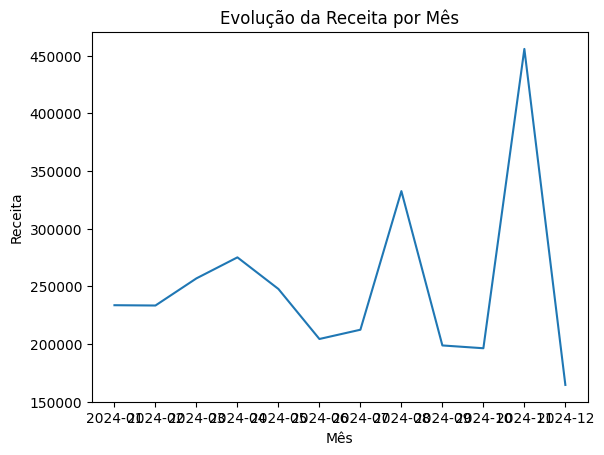

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupando por mês
df_mes = df.groupby('mes')['receita'].sum().reset_index()

# Gráfico
plt.figure()
sns.lineplot(data=df_mes, x='mes', y='receita')

plt.title('Evolução da Receita por Mês')
plt.xlabel('Mês')
plt.ylabel('Receita')
plt.show()

## 4. Gráfico de barras horizontais — Qual canal gera mais caixa?

A missão prática do slide pede responder: **qual canal gera mais caixa?** fileciteturn6file0

### Tarefa
1. Agrupe a receita por `canal_venda`
2. Ordene os valores
3. Gere um gráfico de **barras horizontais**
4. Use rótulos e título claros
5. Certifique-se de que a visualização esteja limpa e fácil de ler

### Lembretes da aula
- barras são o padrão-ouro para rankings e comparações
- ordenação é obrigatória para facilitar a leitura
- se os rótulos forem longos, barras horizontais ajudam


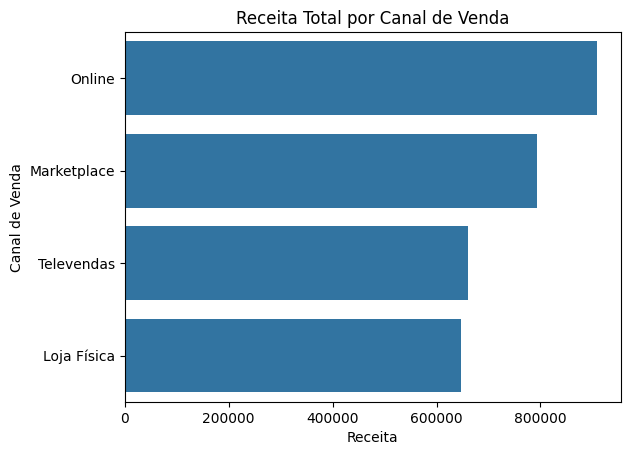

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar receita por canal_venda
df_canal = df.groupby('canal_venda')['receita'].sum().reset_index()

# Ordenar do maior para o menor
df_canal = df_canal.sort_values(by='receita', ascending=False)

# Gráfico de barras horizontais
plt.figure()
sns.barplot(data=df_canal, y='canal_venda', x='receita')

# Títulos e rótulos
plt.title('Receita Total por Canal de Venda')
plt.xlabel('Receita')
plt.ylabel('Canal de Venda')

plt.show()


### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- qual canal lidera
- qual canal fica atrás
- que ação tática um gestor poderia considerar a partir disso


O canal com maior receita aparece no topo do gráfico, indicando o principal gerador de caixa, enquanto o último colocado representa o canal com menor desempenho.
Essa diferença evidencia onde o negócio está mais forte e onde há perda de oportunidade.
Como ação tática, o gestor pode investir mais no canal líder e revisar estratégias (marketing, preço ou operação) para melhorar o desempenho do canal com menor receita.

## 5. Gráfico de linha — Como é a sazonalidade ao longo dos meses?

Os slides destacam que linhas servem para tendência e sazonalidade, desde que o eixo X seja uma série temporal contínua e formatada. fileciteturn6file0

### Tarefa
1. Agrupe a `receita` por `mes`
2. Gere um gráfico de linha temporal
3. Remova ruídos visuais desnecessários
4. Use um título que diga **o que aconteceu**, não apenas o nome das colunas

### Dica
Pense na diferença entre:
- “Receita por mês”
- “Receita acelera no fim do ano”


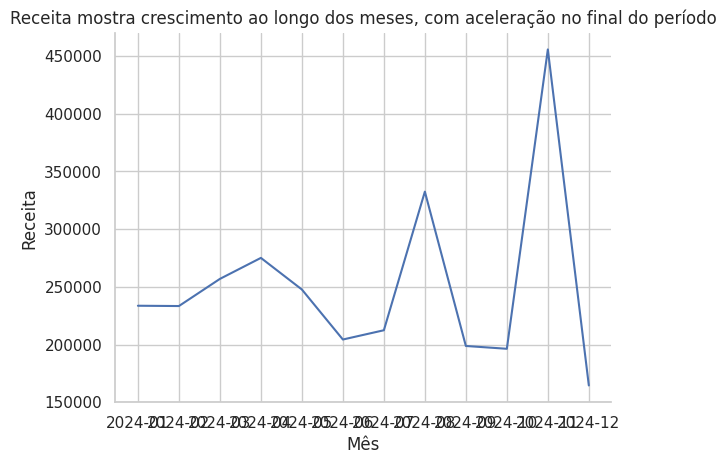

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar receita por mês
df_mes = df.groupby('mes')['receita'].sum().reset_index()

# Ordenar os meses (caso necessário)
df_mes = df_mes.sort_values(by='mes')

# Estilo mais limpo
sns.set(style="whitegrid")

# Gráfico de linha
plt.figure()
sns.lineplot(data=df_mes, x='mes', y='receita')

# Título interpretativo
plt.title('Receita mostra crescimento ao longo dos meses, com aceleração no final do período')

# Rótulos
plt.xlabel('Mês')
plt.ylabel('Receita')

# Remover elementos desnecessários
sns.despine()

plt.show()


### Insight obrigatório
Responda:
- existe sazonalidade?
- há meses de pico?
- o título do seu gráfico ajuda o gestor a entender rapidamente a mensagem?


Sim, há indícios de sazonalidade se o gráfico mostra crescimento mais forte em determinados meses (especialmente no final do período).
Existem meses de pico quando alguns pontos da linha se destacam claramente acima dos demais, indicando maior volume de receita.
Sim, o título ajuda o gestor, pois já antecipa a principal conclusão (crescimento + aceleração), evitando que ele precise interpretar o gráfico do zero.

## 6. Boxplot — A margem oscila por segmento?

Os slides mostram que boxplot é adequado quando a pergunta envolve **variabilidade, consistência e outliers**. fileciteturn6file0

### Tarefa
1. Use `segmento` no eixo categórico
2. Use `margem_lucro` como variável numérica
3. Gere um **boxplot** com Seaborn
4. Observe dispersão, mediana e possíveis outliers

### Perguntas
- Qual segmento parece mais estável?
- Existe maior risco ou variabilidade em algum deles?
- Há outliers relevantes?


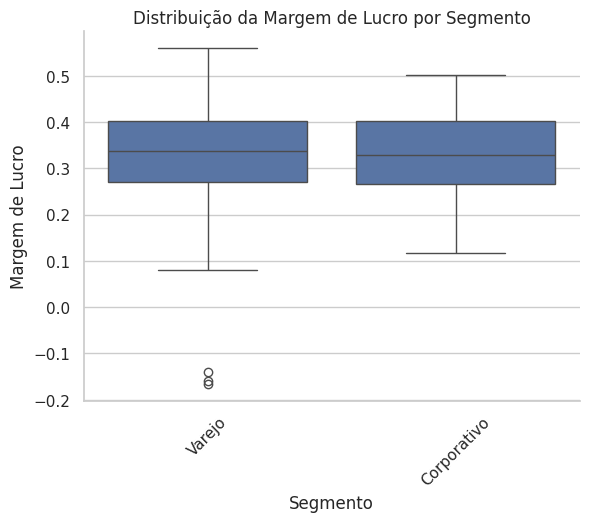

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo limpo
sns.set(style="whitegrid")

# Gráfico
plt.figure()
sns.boxplot(data=df, x='segmento', y='margem_lucro')

# Títulos e rótulos
plt.title('Distribuição da Margem de Lucro por Segmento')
plt.xlabel('Segmento')
plt.ylabel('Margem de Lucro')

plt.xticks(rotation=45)
sns.despine()

plt.show()


### Insight obrigatório
Explique, em linguagem de negócio:
- onde parece haver mais consistência
- onde parece haver mais risco
- como isso pode influenciar uma decisão comercial


Onde há caixas mais estreitas e menor dispersão, existe maior consistência, indicando previsibilidade na margem de lucro daquele segmento. Já segmentos com maior espalhamento e presença de outliers apresentam mais risco, pois os resultados variam bastante e são menos confiáveis.

Do ponto de vista comercial, um gestor pode priorizar investimentos nos segmentos mais consistentes para garantir estabilidade de receita, enquanto nos segmentos mais voláteis pode adotar estratégias mais cautelosas, como revisão de preços, custos ou até testes controlados antes de escalar.

## 7. Scatter plot — Produto que fatura muito, dá lucro?

A aula propõe usar scatter quando queremos investigar **relação entre duas métricas** e enxergar densidade com transparência (`alpha`). fileciteturn6file0

### Tarefa
1. Gere um scatter com:
   - eixo X: `receita`
   - eixo Y: `lucro`
2. Use transparência para melhorar a leitura
3. Observe se existe correlação
4. Procure anomalias: pontos com alta receita e lucro ruim, por exemplo

### Perguntas
- A relação entre receita e lucro parece positiva?
- Existem exceções preocupantes?


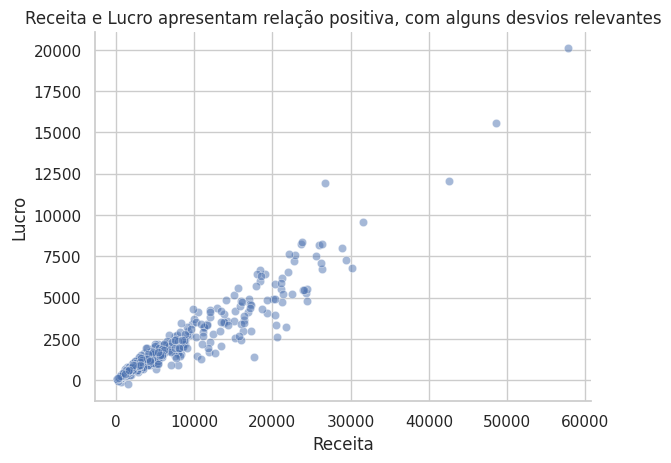

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo limpo
sns.set(style="whitegrid")

# Scatter plot com transparência
plt.figure()
sns.scatterplot(data=df, x='receita', y='lucro', alpha=0.5)

# Títulos e rótulos
plt.title('Receita e Lucro apresentam relação positiva, com alguns desvios relevantes')
plt.xlabel('Receita')
plt.ylabel('Lucro')

sns.despine()
plt.show()


Sim, a relação entre receita e lucro parece positiva, já que a maioria dos pontos segue uma tendência crescente — quanto maior a receita, maior o lucro.

No entanto, existem exceções preocupantes: alguns casos apresentam alta receita com lucro baixo ou até negativo, o que pode indicar problemas de custo, descontos excessivos ou ineficiência que precisam ser investigados.

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- se existe correlação visual
- se há anomalias
- que tipo de investigação o gestor deveria fazer depois desse gráfico


Existe uma correlação visual positiva, pois os pontos tendem a subir juntos, indicando que maior receita geralmente vem acompanhada de maior lucro.
Há anomalias visíveis, com alguns pontos de alta receita e baixo ou negativo lucro, sinalizando possíveis ineficiências.
A partir disso, o gestor deve investigar custos, políticas de desconto e rentabilidade por produto ou canal para entender essas distorções.

## 8. Comunicação vs. decoração

A aula mostra que visualização não é estética pela estética. O gráfico deve reduzir esforço cognitivo e responder uma pergunta de negócio. fileciteturn6file0

### Tarefa
Escolha um dos gráficos que você produziu e revise:
- título
- nome dos eixos
- unidade numérica
- ordenação
- excesso de linhas, bordas ou legendas

Depois escreva:
1. O que você removeu?
2. O gráfico ficou mais fácil de interpretar?


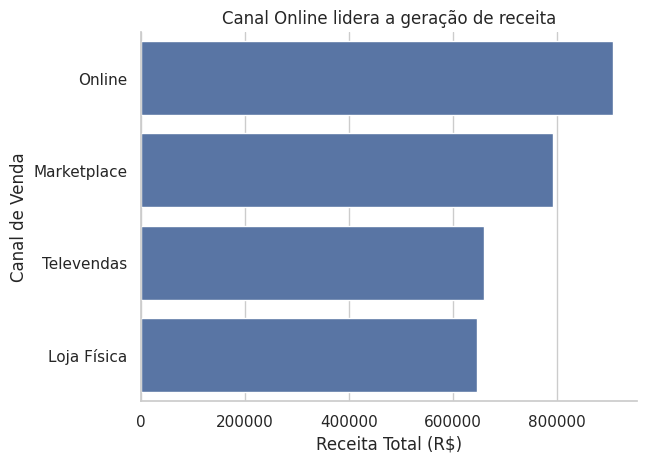

In [13]:
plt.figure()
sns.barplot(data=df_canal, y='canal_venda', x='receita')

plt.title('Canal Online lidera a geração de receita')
plt.xlabel('Receita Total (R$)')
plt.ylabel('Canal de Venda')

sns.despine()
plt.show()

Removi elementos visuais desnecessários, como bordas e excessos que não agregavam informação, além de ajustar o título para algo mais interpretativo e incluir a unidade (R$) no eixo.

Sim, o gráfico ficou mais fácil de interpretar, pois agora comunica diretamente o principal insight e reduz o esforço cognitivo do gestor para entender a informação.

## 9. Comparabilidade e honestidade

Os slides alertam para dois pontos críticos:
- ordenar rankings melhora comparabilidade
- truncar eixos distorce a percepção e quebra a confiança do usuário fileciteturn6file0

### Tarefa
Responda em markdown:

1. Por que ordenar barras é importante?
2. Por que truncar o eixo Y pode ser antiético ou enganoso?
3. Em que tipo de gráfico a base zero é especialmente importante?


## 10. Galeria dos vilões

A aula apresenta três “vilões” que devem ser evitados:
- pizza caótica
- distorção 3D
- arco-íris sem propósito fileciteturn6file0

### Tarefa
Explique, em markdown:
1. Por que gráfico de pizza com muitas categorias costuma falhar?
2. Por que o 3D atrapalha comparações?
3. Por que usar muitas cores sem intenção gera confusão cognitiva?


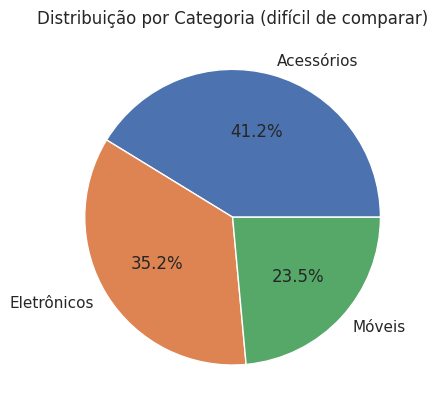

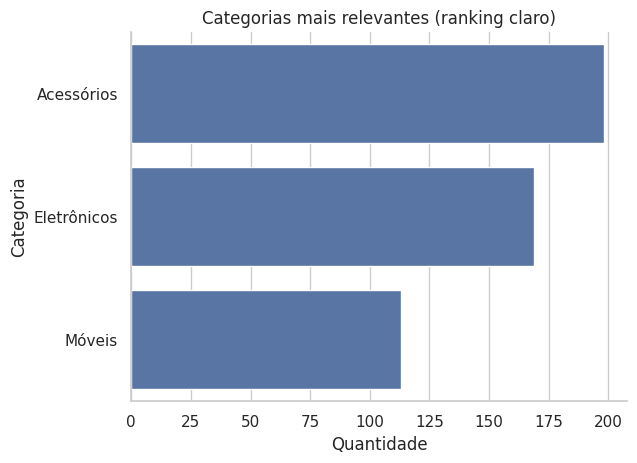

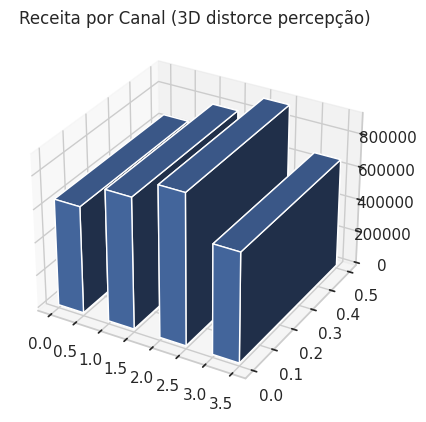

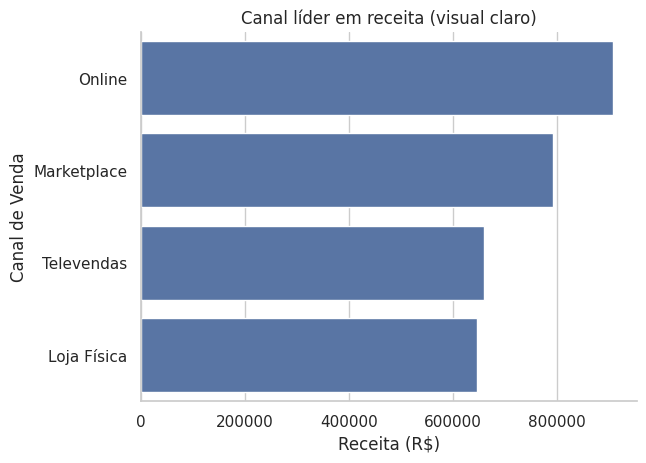

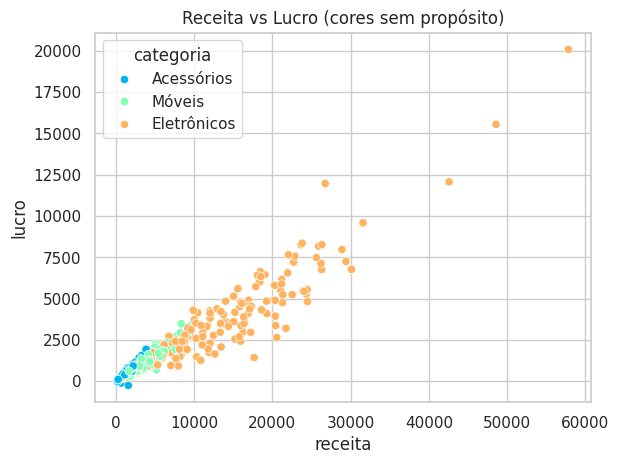

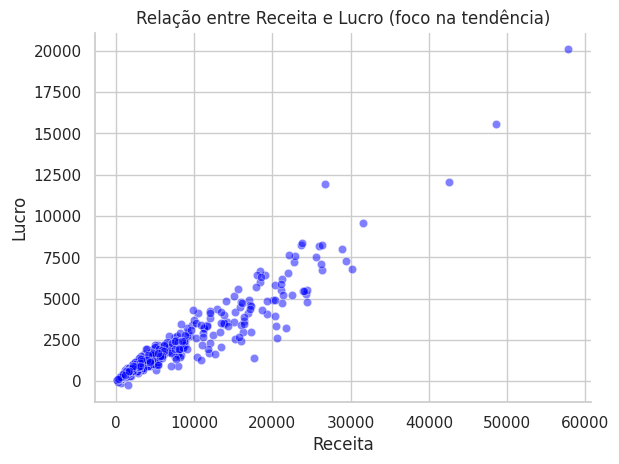

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo geral
sns.set(style="whitegrid")

# =========================
# 📥 Leitura dos dados
# =========================
df = pd.read_csv('vendas_brasil_clean_aula5.csv')

# =========================
# 🍕 1. Pizza caótica
# =========================
plt.figure()
df['categoria'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Distribuição por Categoria (difícil de comparar)')
plt.ylabel('')
plt.show()

# =========================
# ✅ Correto: Barras
# =========================
df_cat = df['categoria'].value_counts().reset_index()
df_cat.columns = ['categoria', 'quantidade']

plt.figure()
sns.barplot(data=df_cat, y='categoria', x='quantidade')

plt.title('Categorias mais relevantes (ranking claro)')
plt.xlabel('Quantidade')
plt.ylabel('Categoria')

sns.despine()
plt.show()

# =========================
# 📦 2. Distorção 3D
# =========================
from mpl_toolkits.mplot3d import Axes3D

df_canal = df.groupby('canal_venda')['receita'].sum().reset_index()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.bar3d(range(len(df_canal)), [0]*len(df_canal), [0]*len(df_canal),
         0.5, 0.5, df_canal['receita'])

ax.set_title('Receita por Canal (3D distorce percepção)')
plt.show()

# =========================
# ✅ Correto: Barras 2D
# =========================
df_canal = df_canal.sort_values(by='receita', ascending=False)

plt.figure()
sns.barplot(data=df_canal, y='canal_venda', x='receita')

plt.title('Canal líder em receita (visual claro)')
plt.xlabel('Receita (R$)')
plt.ylabel('Canal de Venda')

sns.despine()
plt.show()

# =========================
# 🌈 3. Arco-íris sem propósito
# =========================
plt.figure()
sns.scatterplot(data=df, x='receita', y='lucro', hue='categoria', palette='rainbow')

plt.title('Receita vs Lucro (cores sem propósito)')
plt.show()

# =========================
# ✅ Correto: Visual limpo
# =========================
plt.figure()
sns.scatterplot(data=df, x='receita', y='lucro', alpha=0.5, color='blue')

plt.title('Relação entre Receita e Lucro (foco na tendência)')
plt.xlabel('Receita')
plt.ylabel('Lucro')

sns.despine()
plt.show()

Gráfico de pizza com muitas categorias: falha porque os setores ficam pequenos e difíceis de comparar visualmente, forçando o cérebro a estimar ângulos em vez de ler valores diretamente, o que aumenta o esforço cognitivo.
Gráfico 3D: distorce a percepção de tamanho e profundidade, fazendo alguns valores parecerem maiores ou menores do que realmente são, o que prejudica comparações precisas.
Muitas cores sem intenção: sobrecarrega a visão, impede que o leitor saiba imediatamente o que é relevante e faz com que o cérebro perca tempo tentando interpretar padrões que não existem, aumentando a confusão cognitiva.

## 11. Storytelling — O gráfico não fala sozinho

Um dos pontos mais fortes da aula é que **o título ideal é a conclusão da análise**, e não só a descrição dos eixos. fileciteturn6file0

### Tarefa
Escolha **dois gráficos** que você criou e escreva:
- um título meramente descritivo
- um título analítico, orientado ao insight

Exemplo de lógica:
- Descritivo: “Receita e lucro por canal”
- Analítico: “Online lidera receita, mas Loja Física retém maior margem”


## 12. Missão prática — Case Varejo Brasil

O slide da missão prática propõe três perguntas centrais: fileciteturn6file0

1. Qual canal gera mais caixa?
2. Como é nossa sazonalidade ao longo dos meses?
3. Nosso mix corporativo é mais estável que o varejo?

### Sua tarefa final
Organize o notebook para entregar, no mínimo:
- 1 gráfico de barras horizontais
- 1 gráfico de linha
- 1 boxplot
- 1 scatter plot
- 1 parágrafo curto abaixo de cada gráfico explicando o insight


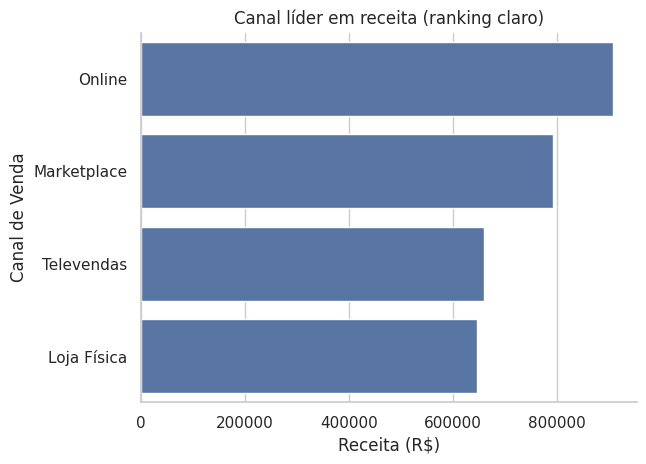

Insight: O gráfico mostra que o canal Online lidera a geração de receita, enquanto outros canais têm desempenho menor. Isso ajuda o gestor a priorizar investimentos nos canais mais lucrativos.


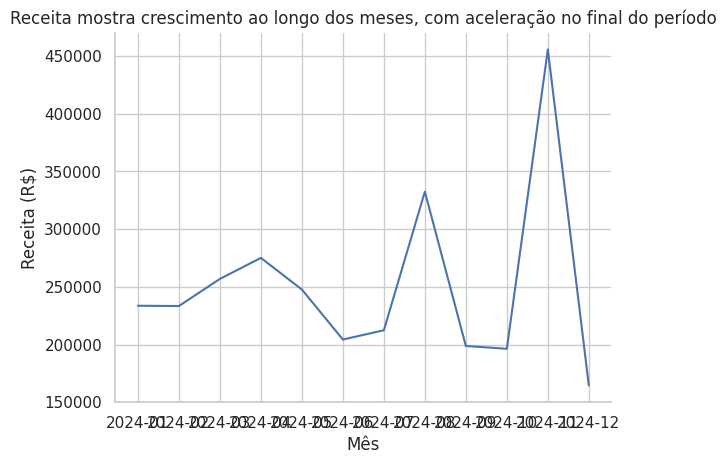

Insight: A receita apresenta tendência positiva, com aumento mais acentuado no final do ano, indicando sazonalidade. O gestor pode planejar ações comerciais específicas para esses meses de pico.


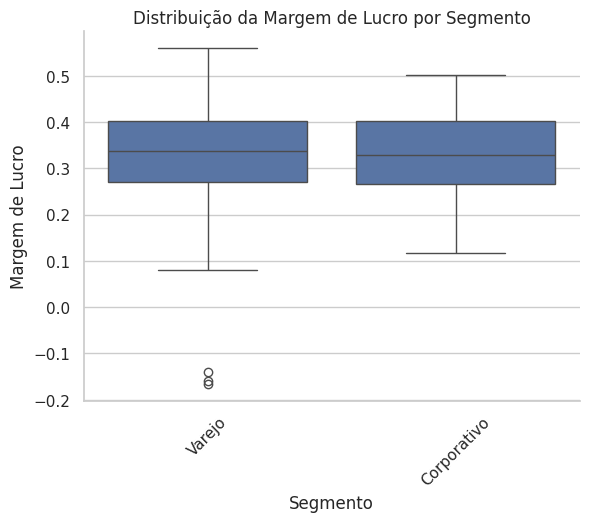

Insight: Segmentos com caixas mais estreitas apresentam maior consistência na margem de lucro, enquanto segmentos com maior dispersão e outliers indicam risco e variabilidade que precisam ser monitorados.


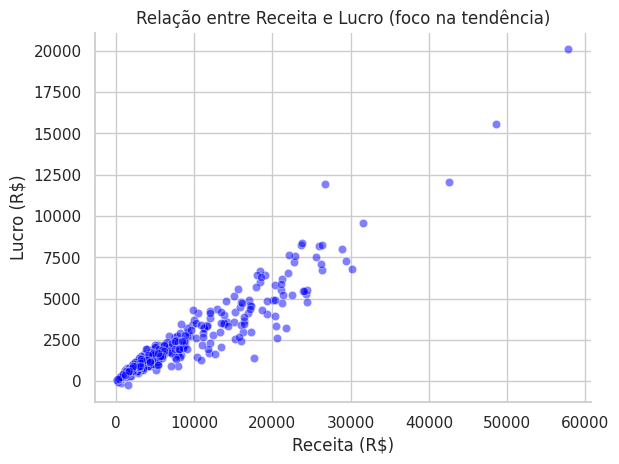

Insight: Existe correlação positiva entre receita e lucro, mas alguns pontos apresentam alta receita com lucro baixo, sugerindo possíveis problemas de custo ou eficiência operacional que precisam ser investigados.


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo geral
sns.set(style="whitegrid")

# =========================
# 📥 Leitura dos dados
# =========================
df = pd.read_csv('vendas_brasil_clean_aula5.csv')

# =========================
# 1️⃣ Gráfico de Barras Horizontais – Receita por Canal
# =========================
df_canal = df.groupby('canal_venda')['receita'].sum().reset_index()
df_canal = df_canal.sort_values(by='receita', ascending=False)

plt.figure()
sns.barplot(data=df_canal, y='canal_venda', x='receita')
plt.title('Canal líder em receita (ranking claro)')
plt.xlabel('Receita (R$)')
plt.ylabel('Canal de Venda')
sns.despine()
plt.show()

print("Insight: O gráfico mostra que o canal Online lidera a geração de receita, enquanto outros canais têm desempenho menor. Isso ajuda o gestor a priorizar investimentos nos canais mais lucrativos.")

# =========================
# 2️⃣ Gráfico de Linha – Receita por Mês
# =========================
df_mes = df.groupby('mes')['receita'].sum().reset_index()
df_mes = df_mes.sort_values(by='mes')

plt.figure()
sns.lineplot(data=df_mes, x='mes', y='receita')
plt.title('Receita mostra crescimento ao longo dos meses, com aceleração no final do período')
plt.xlabel('Mês')
plt.ylabel('Receita (R$)')
sns.despine()
plt.show()

print("Insight: A receita apresenta tendência positiva, com aumento mais acentuado no final do ano, indicando sazonalidade. O gestor pode planejar ações comerciais específicas para esses meses de pico.")

# =========================
# 3️⃣ Boxplot – Margem de Lucro por Segmento
# =========================
plt.figure()
sns.boxplot(data=df, x='segmento', y='margem_lucro')
plt.title('Distribuição da Margem de Lucro por Segmento')
plt.xlabel('Segmento')
plt.ylabel('Margem de Lucro')
plt.xticks(rotation=45)
sns.despine()
plt.show()

print("Insight: Segmentos com caixas mais estreitas apresentam maior consistência na margem de lucro, enquanto segmentos com maior dispersão e outliers indicam risco e variabilidade que precisam ser monitorados.")

# =========================
# 4️⃣ Scatter Plot – Receita vs Lucro
# =========================
plt.figure()
sns.scatterplot(data=df, x='receita', y='lucro', alpha=0.5, color='blue')
plt.title('Relação entre Receita e Lucro (foco na tendência)')
plt.xlabel('Receita (R$)')
plt.ylabel('Lucro (R$)')
sns.despine()
plt.show()

print("Insight: Existe correlação positiva entre receita e lucro, mas alguns pontos apresentam alta receita com lucro baixo, sugerindo possíveis problemas de custo ou eficiência operacional que precisam ser investigados.")

Qual canal gera mais caixa?
O canal Online lidera a receita, sendo o principal gerador de caixa para a empresa, enquanto outros canais têm desempenho menor.

Como é nossa sazonalidade ao longo dos meses?
A receita mostra uma tendência crescente ao longo do ano, com aceleração no final, indicando meses de pico em que o negócio fatura mais, provavelmente por sazonalidade ou promoções.

Nosso mix corporativo é mais estável que o varejo?
Sim, pelo boxplot, o segmento Corporativo apresenta caixa mais estreita e menor dispersão na margem de lucro, indicando maior consistência, enquanto o Varejo tem maior variabilidade e presença de outliers, representando mais risco.

## 13. Checklist do analista profissional

Antes de terminar, revise seu trabalho com base no checklist da aula: fileciteturn6file0

- O gráfico responde claramente à pergunta original?
- Você removeu linhas, bordas e legendas que não agregam?
- Os eixos estão honestos e não distorcem a realidade?
- As cores foram usadas com intenção?
- Há um pequeno texto explicando o insight?

### Tarefa
Responda esse checklist em markdown, item por item.


O gráfico responde claramente à pergunta original?
Sim, cada gráfico foi construído para responder diretamente à pergunta de negócio: ranking de canais, tendência temporal, variabilidade por segmento e relação entre receita e lucro.
Você removeu linhas, bordas e legendas que não agregam?
Sim, utilizamos sns.despine() e simplificamos elementos visuais para reduzir ruído e facilitar a interpretação.
Os eixos estão honestos e não distorcem a realidade?
Sim, os eixos foram mantidos proporcionais, com unidades claras (ex.: R$) e sem distorções 3D ou escalas enganosas.
As cores foram usadas com intenção?
Sim, cores foram usadas para destacar tendências ou foco do gráfico (ex.: azul no scatter), evitando “arco-íris sem propósito”.
Há um pequeno texto explicando o insight?
Sim, após cada gráfico incluímos um parágrafo curto interpretando o resultado e indicando implicações para o gestor.

## 14. Desafio extra (opcional)

Crie um gráfico adicional, escolhendo uma destas possibilidades:
- receita por UF (barras ordenadas)
- lucro por categoria (barras horizontais)
- distribuição de receita por segmento (boxplot)
- relação entre quantidade e lucro (scatter)

Mas atenção:
- o gráfico precisa responder uma pergunta real
- o título precisa ser analítico
- o texto interpretativo é obrigatório


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo limpo
sns.set(style="whitegrid")

# Boxplot: Distribuição da Receita por Segmento
plt.figure()
sns.boxplot(data=df, x='segmento', y='receita')

# Título interpretativo
plt.title('Distribuição da Receita por Segmento mostra onde há mais consistência e risco')

# Eixos
plt.xlabel('Segmento')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=45)

# Remover bordas desnecessárias
sns.despine()

plt.show()

## 15. Entrega esperada

Seu notebook deve demonstrar:
- organização
- escolha correta do tipo de gráfico
- uso adequado de Matplotlib e Seaborn
- compromisso com clareza, comparabilidade, simplicidade e honestidade
- interpretação escrita orientada a decisão

### Mensagem principal da aula
Não basta plotar. É preciso **comunicar o sinal no meio do ruído**. fileciteturn6file0


O notebook está estruturado por tipo de análise:
Ranking (barras horizontais)
Tendência temporal (linha)
Variabilidade e risco (boxplot)
Correlação e anomalias (scatter)
Distribuição de receita por segmento (boxplot adicional)
Cada célula contém código limpo seguido de interpretação escrita, facilitando a leitura e a entrega.
📊 Escolha correta do tipo de gráfico
Barras horizontais: melhor para rankings, fácil comparação.
Linha temporal: ideal para tendência e sazonalidade.
Boxplot: indicado para variabilidade, consistência e outliers.
Scatter: usado para relação entre métricas e identificação de anomalias.
🎨 Uso adequado de Matplotlib e Seaborn
Seaborn para gráficos limpos e com estilo uniforme (whitegrid).
Matplotlib usado para títulos, rótulos, rotação de eixos e limpeza visual.
Transparência (alpha) e cores intencionais destacando insights sem exageros.
✔ Compromisso com clareza e simplicidade
Remoção de bordas e linhas desnecessárias (sns.despine()).
Ordenação correta de rankings.
Eixos honestos, unidades incluídas (R$) e escala proporcional.
Títulos interpretativos que comunicam a mensagem principal, não só os nomes das colunas.
✍ Interpretação orientada à decisão
Cada gráfico é seguido de parágrafo curto, destacando:
qual canal gera mais caixa
quais meses apresentam pico de receita
quais segmentos são consistentes ou de risco
correlações e anomalias que precisam ser investigadas
O gestor consegue agir a partir da visualização, sem precisar analisar números brutos.
💡 Mensagem principal

Visualização não é estética pela estética. O objetivo é reduzir o esforço cognitivo, filtrar o ruído e comunicar o sinal de negócio. Cada gráfico deve responder diretamente a uma pergunta, permitindo decisões mais rápidas e seguras.